In [1]:
import warnings
warnings.filterwarnings(action='ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from binance import Client
from secrets import binance_api_key, binance_secret_key

In [2]:
client = Client(binance_api_key, binance_secret_key)
def get_tickers():
    tickers = []
    for info in client.futures_mark_price():
        ticker = info['symbol']
        if ticker[-4:] == "USDT":
            tickers.append(info['symbol'])
    return tickers

def get_sample(ticker, start_date="1 Jan, 2021"):
    klines = np.array(client.futures_historical_klines(ticker, Client.KLINE_INTERVAL_1DAY, start_date))
    sample = pd.DataFrame(klines.reshape(-1, 12), dtype=float, columns=['datetime',
                                                                        'open', 
                                                                        'high', 
                                                                        'low', 
                                                                        'close', 
                                                                        'volume', 
                                                                        'close time', 
                                                                        'quote asset volume, number of trades', 
                                                                        'number of trades',
                                                                        'taker buy base asset volume', 
                                                                        'taker buy quote asset volume', 
                                                                        'ignore'])
    sample['datetime'] = pd.to_datetime(sample['datetime'], unit='ms')
    sample.set_index('datetime', inplace=True)
    sample = sample[['open', 'high', 'low', 'close', 'volume']].copy()
    return sample

sample = get_sample("BTCUSDT")
sample.tail()

print(len(get_tickers()))

138


In [3]:
tickers = get_tickers()
ref = get_sample("ETHUSDT", start_date="1 Jan, 2020")
pre_samples = dict()
for ticker in tickers:
    sample = get_sample(ticker, start_date="1 Jan, 2020")
    if len(sample) < 220: continue
    
    # preprocess
    sample['noise'] = 1.-abs(sample['close'] - sample['open'])/(sample['high'] - sample['low'])
    sample['noise15'] = sample['noise'].rolling(10).mean()
    sample['target_up'] = sample['open'] + sample['noise15']*(sample.shift(1)['high'] - sample.shift(1)['low'])
    sample['target_down'] = sample['open'] - sample['noise15']*(sample.shift(1)['high'] - sample.shift(1)['low'])
    sample['momentum'] = (sample['close'] - sample.shift(10)['close'])/sample.shift(10)['close']
    sample['reward_up'] = 1. + sample['close'].pct_change()
    sample['reward_down'] = 1. - sample['close'].pct_change()
    sample['log_reward_up'] = np.log(sample['reward_up'])
    sample['log_reward_down'] = np.log(sample['reward_down'])
    sample['total_reward'] = sample['reward_up'].cumprod()
    sample.dropna(inplace=True)
    
    pre_samples[ticker] = sample.copy(); del sample
pre_samples['ETHUSDT'].tail(10)

,open,high,low,close,volume,noise,noise15,target_up,target_down,momentum,reward_up,reward_down,log_reward_up,log_reward_down,total_reward
datetime,,,,,,,,,,,,,,,
2022-01-05,3785.60,3847.18,3405.00,3537.71,1813981.948,0.439391,0.523492,3880.975066,3690.224934,-0.129123,0.934518,1.065482,-0.067725,0.063428,27.083984
2022-01-06,3537.81,3549.11,3292.31,3404.60,1840489.348,0.481269,0.497719,3757.891350,3317.728650,-0.156726,0.962374,1.037626,-0.038352,0.036935,26.064921
2022-01-07,3404.61,3415.35,3040.77,3196.58,2855226.352,0.444631,0.529468,3540.577308,3268.642692,-0.157018,0.938900,1.061100,-0.063046,0.059306,24.472363
2022-01-08,3196.58,3248.03,2996.45,3080.03,1859886.155,0.536728,0.555637,3404.710406,2988.449594,-0.151168,0.963539,1.036461,-0.037142,0.035812,23.580080
2022-01-09,3079.86,3209.40,3057.00,3150.00,1230848.792,0.539764,0.552396,3218.831794,2940.888206,-0.150570,1.022717,0.977283,0.022463,-0.022979,24.115756
2022-01-10,3149.99,3179.16,2924.78,3081.31,2322294.565,0.730010,0.542145,3232.612973,3067.367027,-0.161781,0.978194,1.021806,-0.022048,0.021572,23.589879
2022-01-11,3081.25,3262.66,3050.58,3236.86,1533503.746,0.266267,0.552098,3221.692586,2940.807414,-0.139833,1.050482,0.949518,0.049249,-0.051801,24.780738
2022-01-12,3236.86,3411.00,3203.85,3369.93,1435454.649,0.357615,0.531262,3349.530064,3124.189936,-0.119251,1.041111,0.958889,0.040288,-0.041980,25.799495
2022-01-13,3369.92,3408.89,3230.97,3240.36,1374273.064,0.271808,0.494931,3472.444973,3267.395027,-0.139134,0.961551,1.038449,-0.039208,0.037728,24.807533


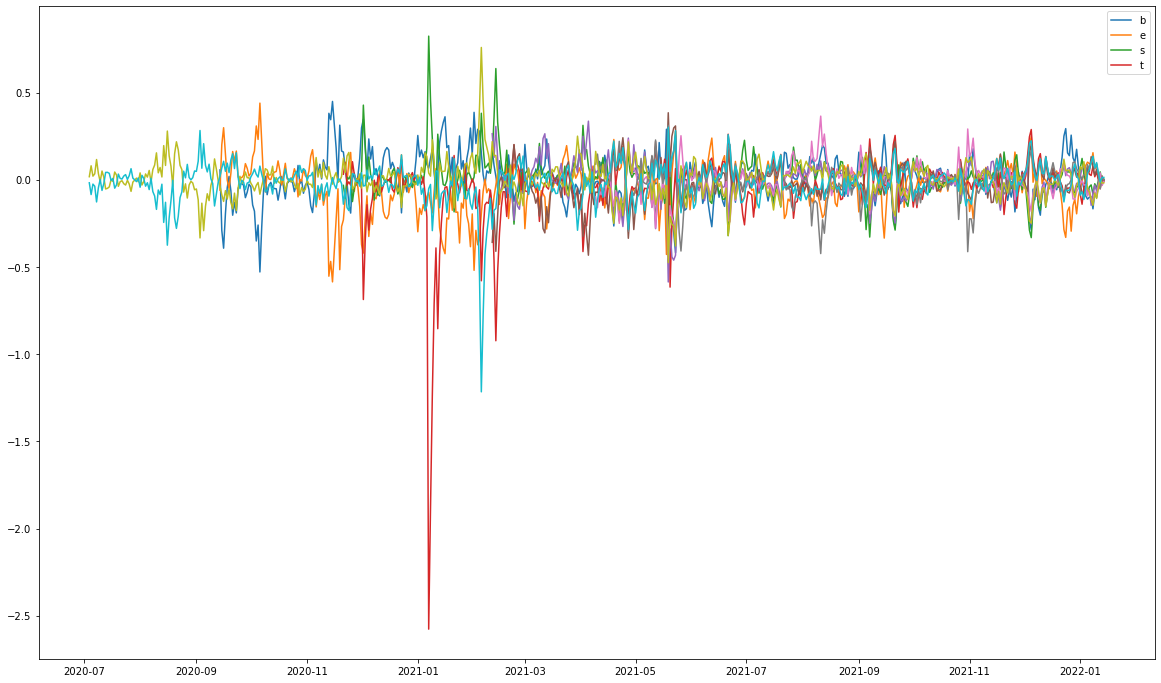

In [4]:
# make value functions
samples = dict()
for ticker in pre_samples.keys():
    sample = pre_samples[ticker].copy()
    sample['value_up'] = 0.
    sample['value_down'] = 0.
    
    for idx in sample.index:
        if idx == sample.index[0]:
            sample.loc[idx, 'value_up'] = sample.loc[idx, 'log_reward_up']
            sample.loc[idx, 'value_down'] = sample.loc[idx, 'log_reward_down']
            continue
        
        gamma = 1. - 0.5*sample.loc[idx, 'noise']
        sample.loc[idx, 'value_up'] = sample.loc[idx, 'log_reward_up'] + gamma*(sample.shift(1).loc[idx, 'value_up'])
        sample.loc[idx, 'value_down'] = sample.loc[idx, 'log_reward_down'] + gamma*(sample.shift(1).loc[idx, 'value_down'])
    samples[ticker] = sample

plt.figure(figsize=(20, 12))
for ticker in list(samples.keys())[:5]:
    plt.plot(samples[ticker].index, samples[ticker].value_up, label=f"{ticker}-up")
    plt.plot(samples[ticker].index, samples[ticker].value_down, label=f"{ticker}-down")
plt.legend('best')
plt.show()

In [5]:
book = samples['BTCUSDT'][['close']].copy()
book['number'] = book.index.map(mdates.date2num)
book['reward'] = 1.
book['value_up'] = 0.
book['value_down'] = 0.

for idx in book.index:
    if idx in [ref.index[0], ref.index[-1]]: continue
    
    # select 21 highest volume coins
    volumes = dict()
    for ticker in samples.keys():
        try:
            volumes[ticker] = samples[ticker].loc[idx, 'close']*samples[ticker].loc[idx, 'volume']
        except:
            continue
    top21v = dict(sorted(volumes.items(), key=(lambda x: x[1]), reverse=True)[:21])
    
    # select 5 up, 5 down
    values = dict()
    for ticker in top21v.keys():
        try:
            values[f"{ticker}-UP"] = samples[ticker].loc[idx, 'value_up']
            values[f"{ticker}-DOWN"] = samples[ticker].loc[idx, 'value_down']
        except:
            continue
    res = dict(sorted(values.items(), key=(lambda x: x[1]), reverse=True)[:6])
    
    book.loc[idx, 'value'] = np.mean(list(res.values()))
    
    reward = 0.
    leverage = 1.
    ratio = 1/len(res)
    
    for coin in res.keys():
        if "UP" in coin:
            ticker = coin[:-3]
            if samples[ticker].loc[idx, 'momentum'] < 0.3:
                reward += ratio
            elif samples[ticker].loc[idx, 'momentum'] < 0.8:
                reward += ratio*(1.+1.*(samples[ticker].shift(-1).loc[idx, 'reward_up']-1.002))
            else:
                if samples[ticker].loc[idx, 'close']/samples[ticker].shift(-1).loc[idx, 'low'] - 1. < -1./4.:
                    reward += 0.
                else:
                    reward += ratio*(1.+4.*(samples[ticker].shift(-1).loc[idx, 'reward_up']-1.002))
        else:
            ticker = coin[:-5]
            if samples[ticker].loc[idx, 'momentum'] > -0.3:
                reward += ratio
            elif samples[ticker].loc[idx, 'momentum'] > -0.6:
                if samples[ticker].loc[idx, 'close']/samples[ticker].shift(-1).loc[idx, 'low'] - 1. < -1./2.:
                    reward += 0.
                else:
                    reward += ratio*(1.+2.*(samples[ticker].shift(-1).loc[idx, 'reward_up']-1.002))
            else:
                if samples[ticker].loc[idx, 'close']/samples[ticker].shift(-1).loc[idx, 'low'] - 1. < -1./12.:
                    reward += 0.
                else:
                    reward += ratio*(1.+12.*(samples[ticker].shift(-1).loc[idx, 'reward_up']-1.002))
    book.loc[idx, 'reward'] = reward
book.dropna(inplace=True)
book.tail(20)    

,close,number,reward,value_up,value_down,value
datetime,,,,,,
2021-12-25,50403.64,18986.0,1.022989,0.0,0.0,0.206813
2021-12-26,50765.73,18987.0,0.952656,0.0,0.0,0.219805
2021-12-27,50707.72,18988.0,0.952399,0.0,0.0,0.144650
2021-12-28,47522.03,18989.0,0.970182,0.0,0.0,0.081481
2021-12-29,46436.54,18990.0,1.022769,0.0,0.0,0.098649
2021-12-30,47095.02,18991.0,0.921358,0.0,0.0,0.132090
2021-12-31,46210.56,18992.0,1.056782,0.0,0.0,0.097032
2022-01-01,47704.35,18993.0,0.972106,0.0,0.0,0.224140
2022-01-02,47280.00,18994.0,1.025185,0.0,0.0,0.159687


==== value trading ====
Accumulated Returns: 198221.13 %
CAGR: 4262.14 %
MDD: -84.0 %
VOL: 233.491 %
Sharpe: 15898.74 %


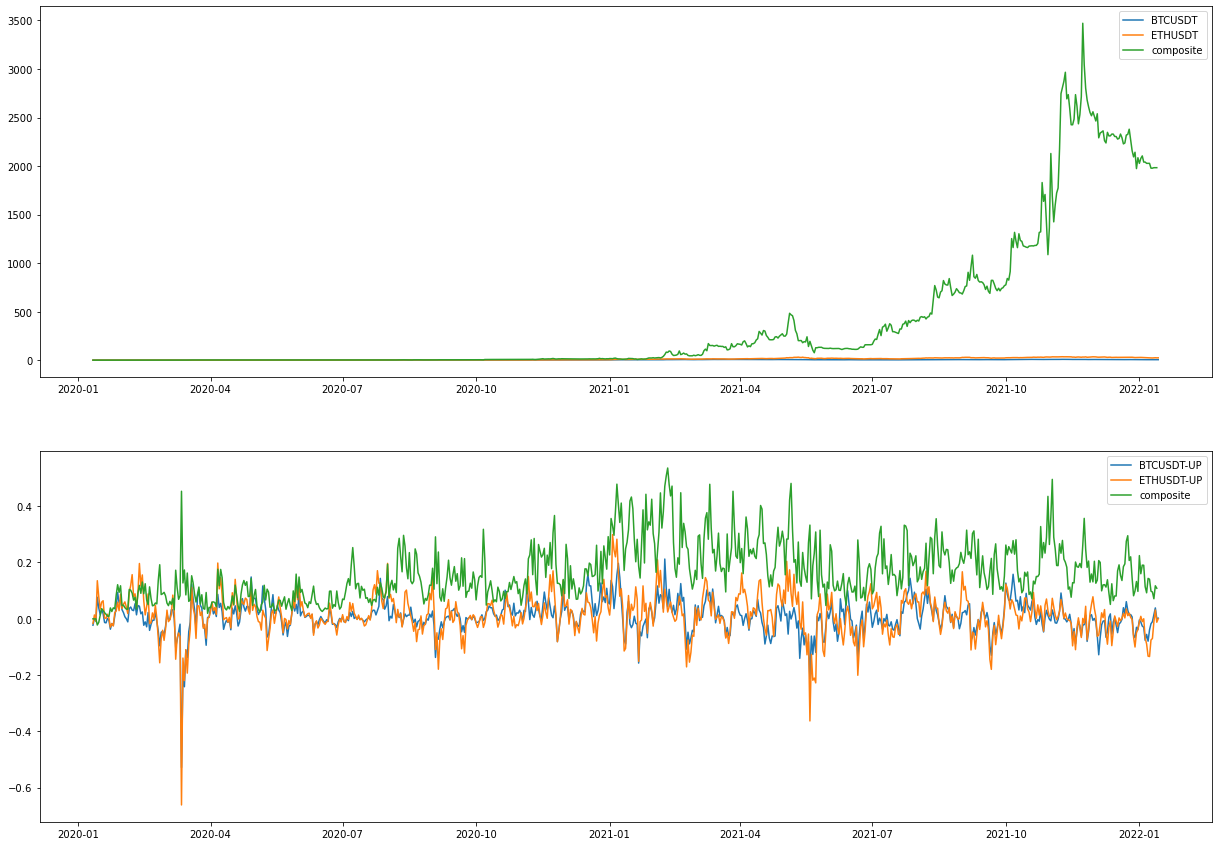

In [6]:
# evaluate
total_reward = 1.
for idx in book.index:
    total_reward *= book.loc[idx, 'reward']
    book.loc[idx, 'total_reward'] = total_reward
CAGR = book['total_reward'].iloc[-1]**(365./len(book.index)) - 1.

historical_max = book['total_reward'].cummax()
daily_drawdown = book['total_reward']/historical_max - 1.
historical_dd = daily_drawdown.cummin()
MDD = historical_dd.min()
VOL = np.std(book['reward'])*np.sqrt(365.)
Sharpe = (np.mean(book['reward'])/np.std(book['reward'])*np.sqrt(365.))

print("==== value trading ====")
print("Accumulated Returns:", round((total_reward-1.)*100, 2), "%")
print("CAGR:", round(CAGR*100, 2), "%")
print("MDD:", round(MDD*100, 2), "%")
print("VOL:", round(VOL*100, 3), "%")
print("Sharpe:", round(Sharpe*100,2), "%")

plt.figure(figsize=(21, 15))
plt.subplot(2, 1, 1)
#plt.yscale('log')
plt.plot(samples['BTCUSDT'].index, samples['BTCUSDT'].total_reward, label="BTCUSDT")
plt.plot(samples['ETHUSDT'].index, samples['ETHUSDT'].total_reward, label="ETHUSDT")
plt.plot(book.index, book.total_reward, label='composite')
plt.legend(loc='best')

plt.subplot(2, 1, 2)
plt.plot(samples['BTCUSDT'].index, samples['BTCUSDT'].value_up, label="BTCUSDT-UP")
plt.plot(samples['ETHUSDT'].index, samples['ETHUSDT'].value_up, label="ETHUSDT-UP")
plt.plot(book.index, book.value, label="composite")
plt.legend(loc='best')

plt.show()